# NB06 - Elastic Net con Titanic

Elastic Net mezcla L1 y L2. Es útil cuando queremos algo de selección de variables sin perder por completo el efecto de agrupamiento de variables correlacionadas.


In [1]:
%matplotlib inline

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks_2":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "data" / "processed"

pd.set_option("display.max_columns", 80)
pd.set_option("display.precision", 4)

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

from src.titanic_utils import (
    RANDOM_STATE,
    load_processed_splits,
    plot_decision_boundary,
    plot_regularization_path,
    set_plot_style,
)

set_plot_style()
data = load_processed_splits(DATA_DIR)
X_train = data["X_train_processed"]
X_test = data["X_test_processed"]
y_train = data["y_train"]
y_test = data["y_test"]
feature_names = data["feature_names"]


## 1. Motivación: variables correlacionadas

`l1_ratio` controla la mezcla: `0` sería Ridge puro y `1` sería Lasso puro. En scikit-learn, Elastic Net requiere `solver="saga"`. Usamos `max_iter=12000` para dar margen de convergencia en todas las mezclas.


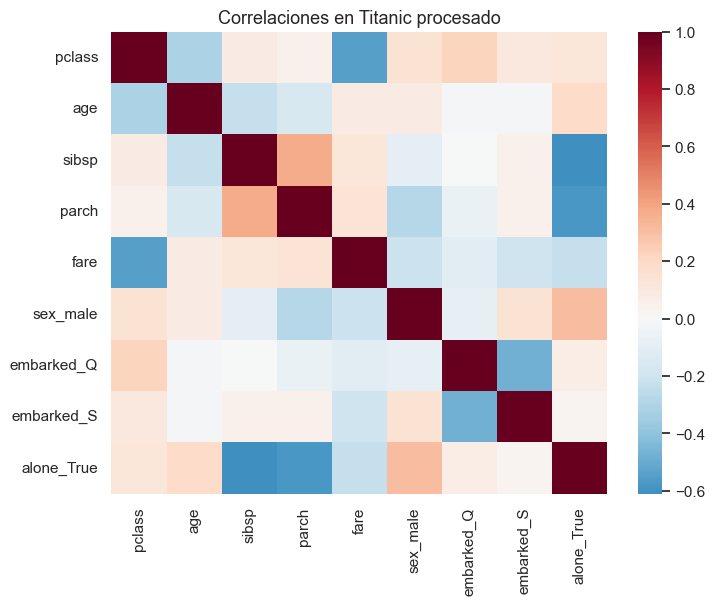

In [2]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(X_train.corr(), cmap="RdBu_r", center=0, ax=ax)
ax.set_title("Correlaciones en Titanic procesado")
plt.show()


## 2. Penalti Elastic Net

Con `penalty="elasticnet"` y `l1_ratio=0.5`, la mitad de la penalización tiene comportamiento L1 y la otra mitad L2. `C` sigue siendo el control inverso de fuerza de penalización.


## 3. Exploración visual de coeficientes

Comparamos rutas para `l1_ratio` bajo, medio y alto. Una mezcla más cercana a L1 produce más ceros; una más cercana a L2 tiende a repartir el peso.


In [3]:
C_values = np.logspace(-3, 2, 10)
l1_ratios = [0.1, 0.5, 0.9]

all_results = []
coef_by_ratio = {}
for l1_ratio in l1_ratios:
    coefs = []
    for C in C_values:
        model = LogisticRegression(
            penalty="elasticnet",
            C=C,
            l1_ratio=l1_ratio,
            solver="saga",
            max_iter=12000,
            tol=1e-4,
            random_state=RANDOM_STATE,
        )
        model.fit(X_train, y_train)
        prob_test = model.predict_proba(X_test)[:, 1]
        coef = model.coef_.ravel()
        coefs.append(coef)
        all_results.append(
            {
                "l1_ratio": l1_ratio,
                "C": C,
                "auc_test": roc_auc_score(y_test, prob_test),
                "variables_no_cero": int((np.abs(coef) > 1e-6).sum()),
            }
        )
    coef_by_ratio[l1_ratio] = np.vstack(coefs)

elastic_results = pd.DataFrame(all_results)
display(elastic_results.sort_values("auc_test", ascending=False).head(10))


,l1_ratio,C,auc_test,variables_no_cero
25,0.9,0.5995,0.8556,9
15,0.5,0.5995,0.8555,9
5,0.1,0.5995,0.8550,9
17,0.5,7.7426,0.8549,9
6,0.1,2.1544,0.8549,9
7,0.1,7.7426,0.8549,9
28,0.9,27.8256,0.8549,9
27,0.9,7.7426,0.8548,9
29,0.9,100.0000,0.8548,9
18,0.5,27.8256,0.8548,9


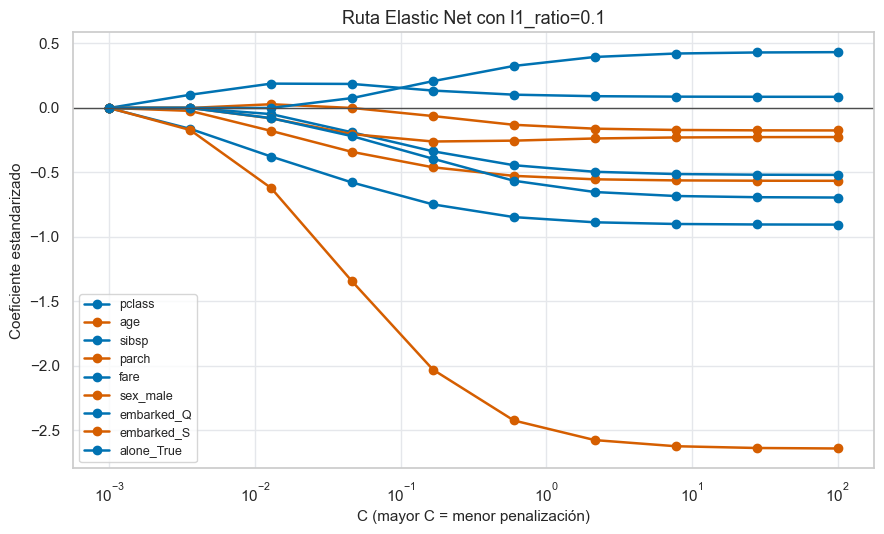

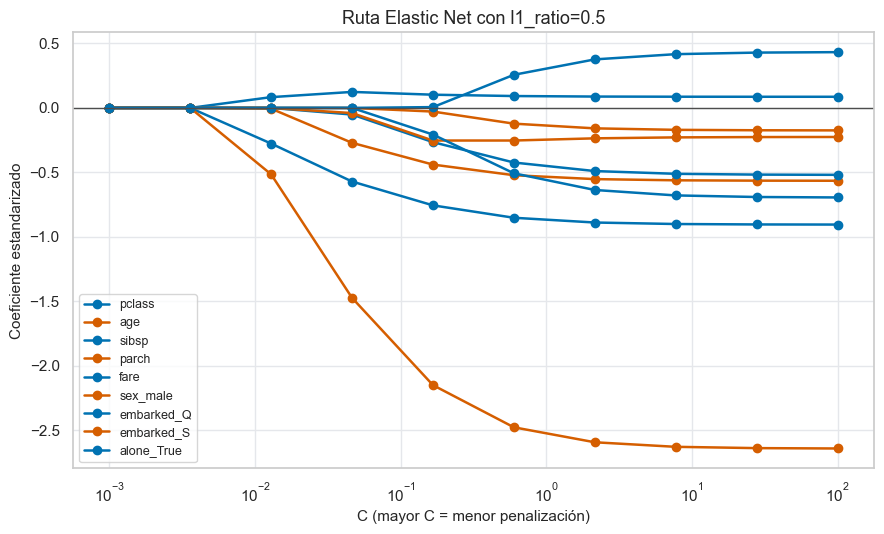

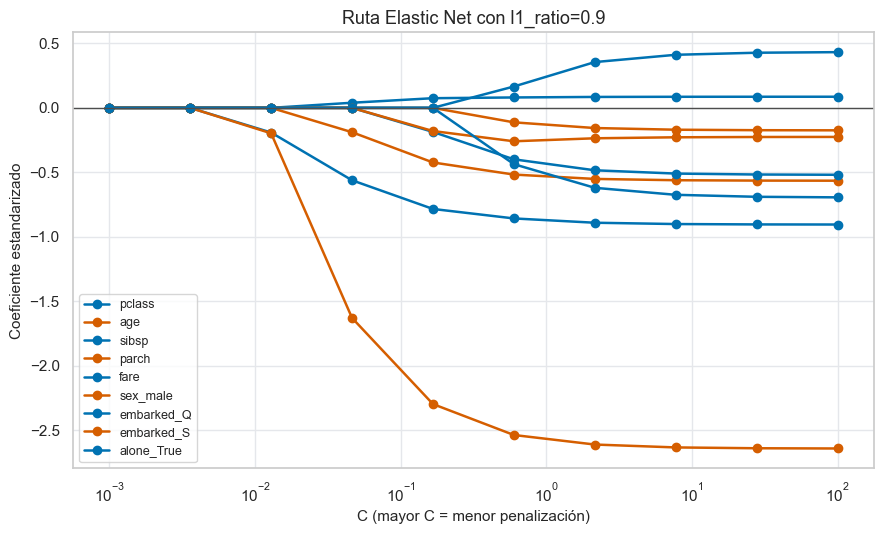

In [4]:
for l1_ratio, coefs in coef_by_ratio.items():
    plot_regularization_path(
        C_values,
        coefs,
        feature_names,
        f"Ruta Elastic Net con l1_ratio={l1_ratio}",
    )
    plt.show()


## 4. Demostración empírica del efecto de agrupamiento

Comparamos coeficientes para el mismo `C=0.3` y distintos `l1_ratio`. Si dos variables están asociadas con la respuesta y entre sí, Elastic Net suele repartir más peso que Lasso puro.


l1_ratio,0.1,0.5,0.9
feature,,,
age,-0.4972,-0.4865,-0.4772
alone_True,-0.4811,-0.3685,-0.2132
embarked_Q,0.2661,0.1374,0.0000
embarked_S,-0.2615,-0.2602,-0.2616
fare,0.1171,0.0969,0.0766
parch,-0.0992,-0.0807,-0.0564
pclass,-0.8022,-0.8098,-0.8227
sex_male,-2.2501,-2.3377,-2.4440
sibsp,-0.3929,-0.3515,-0.2977


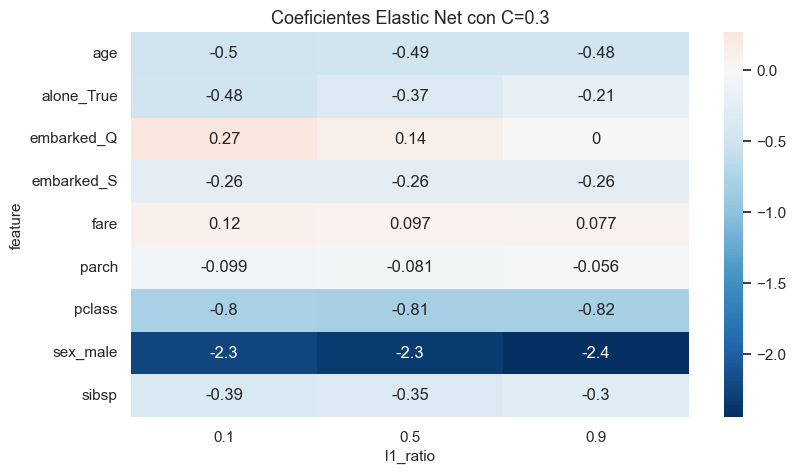

In [5]:
fixed_C = 0.3
coef_rows = []
for l1_ratio in l1_ratios:
    model = LogisticRegression(
        penalty="elasticnet",
        C=fixed_C,
        l1_ratio=l1_ratio,
        solver="saga",
        max_iter=12000,
        tol=1e-4,
        random_state=RANDOM_STATE,
    )
    model.fit(X_train, y_train)
    for feature, coef in zip(feature_names, model.coef_.ravel()):
        coef_rows.append({"l1_ratio": l1_ratio, "feature": feature, "coeficiente": coef})

coef_long = pd.DataFrame(coef_rows)
coef_pivot = coef_long.pivot(index="feature", columns="l1_ratio", values="coeficiente")
display(coef_pivot)

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(coef_pivot, annot=True, cmap="RdBu_r", center=0, ax=ax)
ax.set_title(f"Coeficientes Elastic Net con C={fixed_C}")
plt.show()


## 5. Frontera de decisión Elastic Net en 2D

Usamos la mejor combinación observada en prueba para una visualización parcial con edad y tarifa. La selección rigurosa se hará con validación cruzada en NB07.


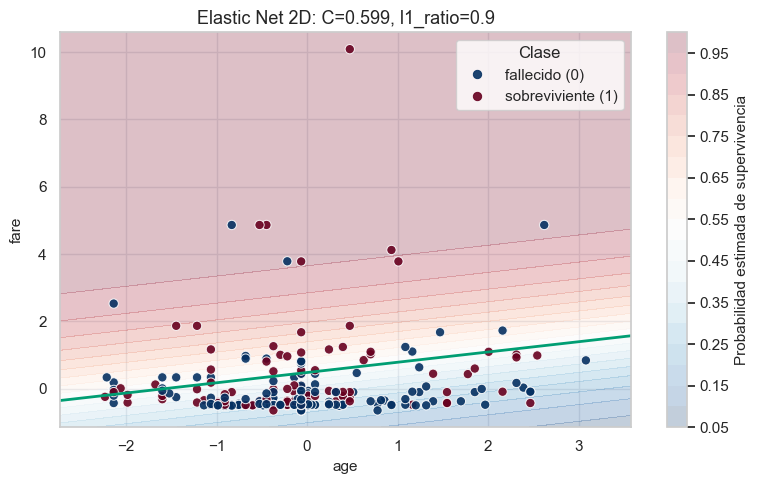

In [6]:
best_row = elastic_results.sort_values("auc_test", ascending=False).iloc[0]
two_features = ["age", "fare"]

model_2d = LogisticRegression(
    penalty="elasticnet",
    C=float(best_row["C"]),
    l1_ratio=float(best_row["l1_ratio"]),
    solver="saga",
    max_iter=12000,
    tol=1e-4,
    random_state=RANDOM_STATE,
)
model_2d.fit(X_train[two_features], y_train)

plot_decision_boundary(
    model_2d,
    X_test[two_features],
    y_test,
    two_features,
    f"Elastic Net 2D: C={best_row['C']:.3g}, l1_ratio={best_row['l1_ratio']}",
)
plt.show()


## Resumen y conexión con la literatura

Elastic Net combina selección y agrupamiento. Es una respuesta práctica a la inestabilidad de Lasso cuando hay predictores correlacionados, tal como proponen Zou y Hastie. En scikit-learn, SAGA permite optimizar esta penalización compuesta.
